###RAG pipeline using Chroma DB

In [2]:
# Install dependencies
!pip -q install chromadb sentence-transformers langchain_text_splitters pypdf groq

In [3]:
import pypdf


PDF_INPUT_FILE_PATH = "Career Transition.pdf"

def extract_pages_from_pdf(file_path: str) -> list[str]:
    """
    Reads a PDF file and returns text page by page.

    Returns:
        list[str]: Each item is text from one PDF page.
    """
    reader = pypdf.PdfReader(file_path)

    pages_text = []

    for page in reader.pages:
        text = page.extract_text()

        if text:
            pages_text.append(text)
        else:
            pages_text.append("")

    return pages_text


pages_text = extract_pages_from_pdf(PDF_INPUT_FILE_PATH)

print(f"Total pages: {len(pages_text)}")



Total pages: 11


In [4]:
CHUNK_SIZE = 1000
SOURCE_NAME = "Career Transition.pdf"


def parse_word_chunks_by_page(
    pages_text: list[str],
    chunk_size: int = CHUNK_SIZE
) -> list[dict]:
    chunks = []

    for page_num, page_text in enumerate(pages_text, start=1):
        # Strip markdown heading symbols and blank lines
        clean_lines = []

        for line in page_text.splitlines():
            line = line.strip().lstrip("#").strip()

            if line:
                clean_lines.append(line)

        # Join page text into one word list and slice
        words = " ".join(clean_lines).split()

        for start in range(0, len(words), chunk_size):
            content = " ".join(words[start : start + chunk_size])

            chunks.append({
                "chunk_index": len(chunks),
                "page_chunk_index": start // chunk_size,
                "content": content,
                "source": SOURCE_NAME,
                "page": page_num,
            })

    return chunks

In [11]:
'''
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=150,
    separators=["\n\n", "\n", ". ", " ", ""],
)

chunks = []

for page_num, page_text in enumerate(pages_text, start=1):
    page_chunks = text_splitter.split_text(page_text)

    for chunk_index, chunk_text in enumerate(page_chunks):
        chunks.append({
            "content": chunk_text,
            "page": page_num,
            "chunk_index": chunk_index,
            "source": "your_pdf_name.pdf"
        })

print(f"Created {len(chunks)} chunks")

'''

NameError: name 'pages_text' is not defined

In [5]:
chunks = parse_word_chunks_by_page(pages_text)

print(f"Total chunks: {len(chunks)}")

for chunk in chunks[:3]:
    print("─" * 60)
    print("Chunk index:", chunk["chunk_index"])
    print("Page:", chunk["page"])
    print("Page chunk index:", chunk["page_chunk_index"])
    print("Content:", chunk["content"][:300])

Total chunks: 11
────────────────────────────────────────────────────────────
Chunk index: 0
Page: 1
Page chunk index: 0
Content: Figure: Illustrative pathway of a backend engineer transitioning into an AI/LLM-focused role. From Backend Engineer to AI Product/Architect: A Comprehensive LLM Skills & Tools Guide Introduction The explosion of AI and Large Language Models (LLMs) is reshaping software roles. Backend engineers, with
────────────────────────────────────────────────────────────
Chunk index: 1
Page: 2
Page chunk index: 0
Content: API Development & Integration – Proficiency in building robust APIs and microservices that expose AI capabilities. As LLM-powered features often live behind APIs (e.g. a text generation endpoint), strong API design and security skills are vital. Performance Optimization & Model Serving – Skills in o
────────────────────────────────────────────────────────────
Chunk index: 2
Page: 3
Page chunk index: 0
Content: Vector Databases (Pinecone, Weaviate, etc.

In [6]:
# Inspect a chunk
for chunk in chunks[:3]:
    print("─" * 55)
    print(f"Content : {chunk['content'][:200]}…")

───────────────────────────────────────────────────────
Content : Figure: Illustrative pathway of a backend engineer transitioning into an AI/LLM-focused role. From Backend Engineer to AI Product/Architect: A Comprehensive LLM Skills & Tools Guide Introduction The e…
───────────────────────────────────────────────────────
Content : API Development & Integration – Proficiency in building robust APIs and microservices that expose AI capabilities. As LLM-powered features often live behind APIs (e.g. a text generation endpoint), str…
───────────────────────────────────────────────────────
Content : Vector Databases (Pinecone, Weaviate, etc.) – Since LLMs often need external knowledge, vector DBs are used to enable fast similarity search on embeddings (for the RAG pattern). Pinecone and Weaviate …


In [7]:
def build_chunk_text(chunk: dict) -> str:
    return chunk["content"]

In [8]:
from sentence_transformers import SentenceTransformer

EMBEDDING_MODEL = "all-MiniLM-L6-v2"
embedder = SentenceTransformer(EMBEDDING_MODEL)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [9]:
# Extract Chunk Texts
chunk_texts = [build_chunk_text(c) for c in chunks]

print(f"Embedding {len(chunk_texts)} chunks …")
embeddings = embedder.encode(chunk_texts, show_progress_bar=True)

print(f"Shape: {embeddings.shape}")

Embedding 11 chunks …


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Shape: (11, 384)


In [10]:
import chromadb


chroma_client = chromadb.PersistentClient("./tmp/my_chromadb")
collection = chroma_client.create_collection(name="my_pdf_collection")

ids = [f"chunk_{i}" for i in range(len(chunk_texts))]

metadatas = [
    {
        "source": "Career Transition.pdf",
        "chunk_index": i,
        "page": chunk.get("page", -1)
    }
    for i, chunk in enumerate(chunks)
]

collection.add(
    ids=ids,
    documents=chunk_texts,
    embeddings=embeddings.tolist(),
    metadatas=metadatas
)

print(f"Inserted {len(chunk_texts)} chunks into ChromaDB")


Inserted 11 chunks into ChromaDB


In [11]:
# ChromaDB
print(f"Records    : {collection.count()}")

sample = collection.get(include=["embeddings"], limit=1)
print(f"Dimensions : {len(sample['embeddings'][0])}")

Records    : 11
Dimensions : 384


In [12]:
def retrieve(
    query: str,
    top_k: int = 5
) -> list[dict]:
    """
    Embed the query and return the top-k most similar chunks.

    Args:
        query : User's question.
        top_k : Number of chunks to return.
    """
    query_vector = embedder.encode(query).tolist()

    results = collection.query(
        query_embeddings=[query_vector],
        n_results=top_k,
        include=["documents", "metadatas", "distances"]
    )

    retrieved_chunks = []

    for doc, metadata, distance in zip(
        results["documents"][0],
        results["metadatas"][0],
        results["distances"][0]
    ):
        retrieved_chunks.append({
            **metadata,
            "content": doc,
            "distance": round(distance, 4)
        })

    return retrieved_chunks

In [13]:
print(chunks[0])

{'chunk_index': 0, 'page_chunk_index': 0, 'content': 'Figure: Illustrative pathway of a backend engineer transitioning into an AI/LLM-focused role. From Backend Engineer to AI Product/Architect: A Comprehensive LLM Skills & Tools Guide Introduction The explosion of AI and Large Language Models (LLMs) is reshaping software roles. Backend engineers, with their strength in scalable systems and APIs, are uniquely positioned to move into AI-focused product or architecture roles . Transitioning into these roles doesn’t mean abandoning your backend expertise – instead, it means augmenting it with strategic AI/ML skills. This guide outlines the key LLM- related skills, tools, architectural patterns, and learning paths that will help a backend engineer grow into an AI product or architect role. We also include examples of successful transitions and highlight emerging trends in the AI tools market. Let’s dive in. Essential AI/LLM Skills for Backend Engineers Growing into an AI/LLM-centric role r

In [14]:
results = retrieve("What is this PDF about?", top_k=5)

for chunk in results:
    print("─" * 60)
    print("Page:", chunk.get("page"))
    print("Distance:", chunk["distance"])
    print("Content:", chunk["content"][:500])

────────────────────────────────────────────────────────────
Page: 11
Distance: 1.8297
Content: Sources: High-quality references were used to inform this guide, including AI engineering roadmaps , industry case studies on LLM integration best practices, success stories of engineers transitioning to AI roles, and recent reports on AI tools & trends. These citations (formatted as 【source†lines】) can be explored for more detail on each point. How a Backend Engineer Can Become an LLM Engineer or AI Expert: The Rich Roadmap for 2025–2035 | Interview Package https://interviewpackage.com/blog/bac
────────────────────────────────────────────────────────────
Page: 6
Distance: 1.8676
Content: Specialized Topics – If you have specific interests, there are courses on those too. For instance, Retrieval-Augmented Generation and Agent systems have started appearing in course curriculums. An example is “Fundamentals of AI Agents using RAG and LangChain” by IBM on Coursera – covering how to build agent

## **RAG Pipeline**

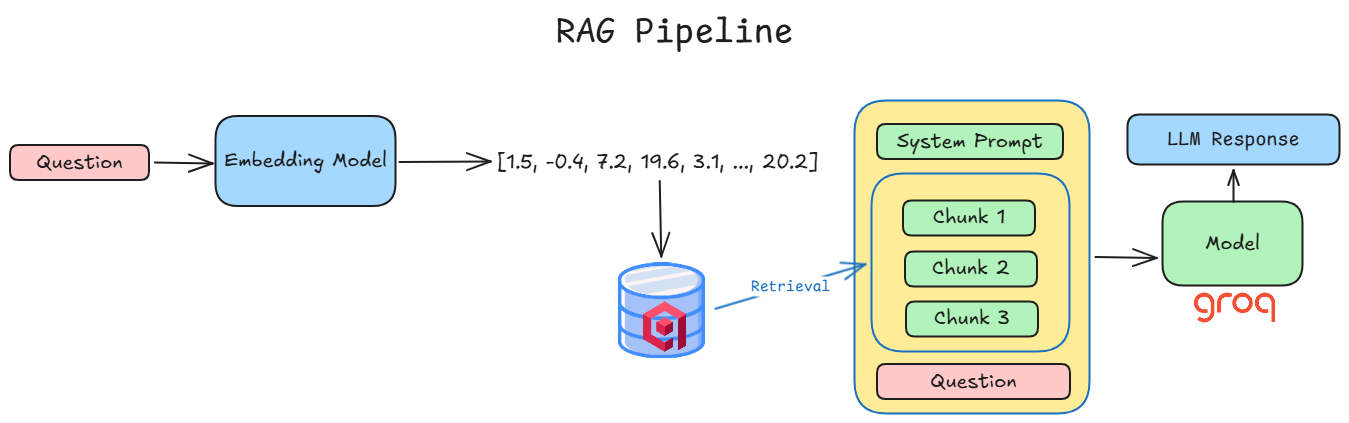

In [19]:
SYSTEM_PROMPT = """You are a helpful career counsellor.
Answer the user's question using ONLY the context provided below.
If the context does not contain enough information, say so — do not make things up.
Always cite the section name when referencing specific information."""

In [15]:
def build_context(retrieved_chunks: list[dict]) -> str:
    parts = []
    for i, chunk in enumerate(retrieved_chunks, 1):
        parts.append(f"[Source {i}]\n{chunk['content']}")
    return "\n\n---\n\n".join(parts)

In [16]:
import getpass
import os

if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = "gsk_xxxxxxxxxxx"

In [23]:
from groq import Groq

groq_client = Groq()   # Reads GROQ_API_KEY from environment automatically
GROQ_MODEL  = "openai/gpt-oss-safeguard-20b"

def rag(query: str, top_k: int = 3):
    """
    End-to-end RAG pipeline:
      1. Retrieve relevant chunks from Qdrant
      2. Format them as a context block
      3. Send context + query to Groq and return the answer
    """
    # Step 1 — Retrieve
    chunks = retrieve(query, top_k=top_k)
    if not chunks:
        return "No relevant content found in the document."

    # Step 2 — Build context
    context = build_context(chunks)

    # Step 3 — Generate
    user_message = f"Context:\n{context}\n\nQuestion: {query}"


    print(f"{SYSTEM_PROMPT}\n\n{user_message}")
    response = groq_client.chat.completions.create(
        model=GROQ_MODEL,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": user_message},
        ],
        temperature=0.2,   # Low = factual;  High = creative
    )
    return response.choices[0].message.content, context

In [20]:
answer, context = rag("What are the main topics covered in this document?")
print(answer)
print(f"{250*'='}")
print(f"\n\nSOURCES:\n {context}")

You are a helpful career counsellor.
Answer the user's question using ONLY the context provided below.
If the context does not contain enough information, say so — do not make things up.
Always cite the section name when referencing specific information.

Context:
[Source 1]
Specialized Topics – If you have specific interests, there are courses on those too. For instance, Retrieval-Augmented Generation and Agent systems have started appearing in course curriculums. An example is “Fundamentals of AI Agents using RAG and LangChain” by IBM on Coursera – covering how to build agents that use tools and retrieval. Keep an eye on new offerings, as the ecosystem evolves fast. Certifications to Consider: NVIDIA’s Generative AI Certification – NVIDIA has introduced the NVIDIA Certified Associate (NCA) – Generative AI with LLMs certification, which “validates foundational concepts for developing, integrating, and maintaining AI-driven applications using generative AI and LLMs”. This could be a go

In [21]:
answer, context = rag("How to transition from Backend API developer to AI role?")
print(answer)
print(f"{250*'='}")
print(f"\n\nSOURCES:\n {context}")

You are a helpful career counsellor.
Answer the user's question using ONLY the context provided below.
If the context does not contain enough information, say so — do not make things up.
Always cite the section name when referencing specific information.

Context:
[Source 1]
Transitioning from Backend to AI Product/Architect Roles: Tips and Examples Making the leap to an AI-focused product or architecture role often involves a combination of self-driven upskilling and strategic projects at work. Here are some actionable tips, along with an example of a successful transition: Leverage Your Current Role for AI Projects: Look for opportunities in your current job to integrate AI features. For instance, you might propose a hackathon project to add an intelligent recommendation engine or an automated summarization tool to your product. Real-world implementation at work is gold – it demonstrates initiative and yields talking points for future AI role interviews. Many backend engineers transi

In [24]:
answer, context = rag("What is the current temp of Bangalore?")
print(answer)
print(f"{250*'='}")
print(f"\n\nSOURCES:\n {context}")

You are a helpful career counsellor.
Answer the user's question using ONLY the context provided below.
If the context does not contain enough information, say so — do not make things up.
Always cite the section name when referencing specific information.

Context:
[Source 1]
Vector Databases (Pinecone, Weaviate, etc.) – Since LLMs often need external knowledge, vector DBs are used to enable fast similarity search on embeddings (for the RAG pattern). Pinecone and Weaviate are examples of managed vector DB services that many teams use to store document embeddings. Understanding how to generate embeddings (e.g. using OpenAI or SentenceTransformers) and query a vector index is key for building systems that augment LLMs with proprietary data. Retrieval-Augmented Generation (RAG) – Not a tool per se, but a crucial architecture pattern to learn. RAG involves retrieving relevant data (from a database or knowledge base) and feeding it into the LLM’s prompt to ground its answers. This helps ensu